In [1]:
print("hello world")

hello world


Matplotlib is building the font cache; this may take a moment.


TypeError: Image data of dtype object cannot be converted to float

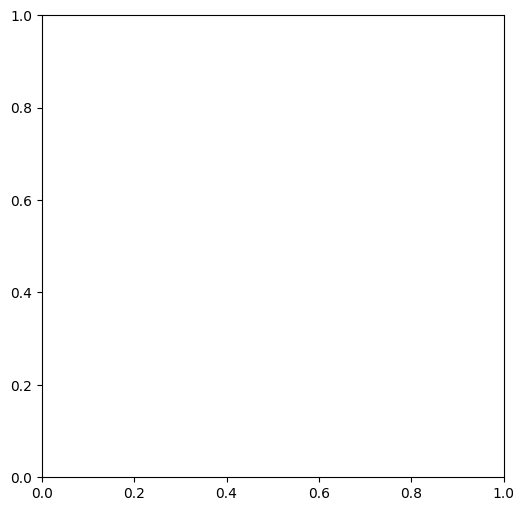

In [2]:
import cv2
import matplotlib.pyplot as plt

# Load one image from your dataset
img = cv2.imread('../data/images/train/train/clean/1.pgm', cv2.IMREAD_GRAYSCALE)

# Show it
plt.figure(figsize=(6,6))
plt.imshow(img, cmap='gray')
plt.title('Cover image loaded successfully')
plt.axis('off')
plt.show()

print("Image shape:", img.shape)

In [4]:
import cv2
import matplotlib.pyplot as plt
import os

# First, let's find what files actually exist
folder = '../data/images/train/train/clean'
files = os.listdir(folder)
print("Files found:", files[:5])  # shows first 5 filenames

Files found: ['00001.png', '00002.png', '00003.png', '00004.png', '00005.png']


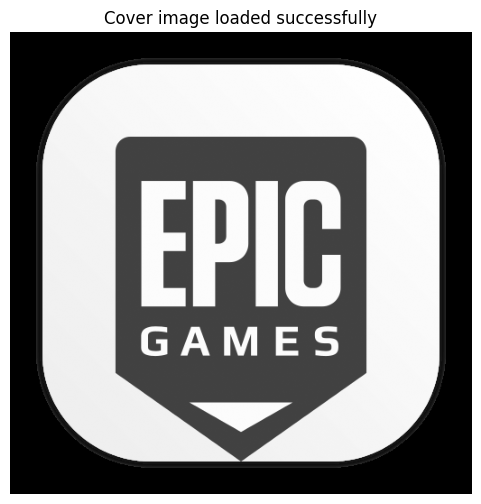

Image shape: (512, 512)


In [5]:
# Load image with correct filename
img = cv2.imread('../data/images/train/train/clean/00001.png', cv2.IMREAD_GRAYSCALE)

# Show it
plt.figure(figsize=(6,6))
plt.imshow(img, cmap='gray')
plt.title('Cover image loaded successfully')
plt.axis('off')
plt.show()

print("Image shape:", img.shape)

In [6]:
import numpy as np
from scipy.fftpack import dct

# Extract DCT features (core of image steganalysis)
dct_coeffs = dct(dct(img.T, norm='ortho').T, norm='ortho')

# Feature vector
features = {
    'mean': round(np.mean(dct_coeffs), 4),
    'std': round(np.std(dct_coeffs), 4),
    'variance': round(np.var(dct_coeffs), 4),
    'skewness': round(float(np.mean((dct_coeffs - np.mean(dct_coeffs))**3)), 4),
    'energy': round(np.sum(dct_coeffs**2), 2)
}

print("=== Image Feature Vector ===")
for k, v in features.items():
    print(f"  {k}: {v}")

=== Image Feature Vector ===
  mean: 0.0209
  std: 160.9133
  variance: 25893.0769
  skewness: 892997558.0864
  energy: 6787714871.0


In [1]:
# Visualise DCT coefficients - good figure for your dissertation
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(np.log(np.abs(dct_coeffs) + 1), cmap='hot')
plt.title('DCT coefficient map')
plt.colorbar()
plt.axis('off')

plt.suptitle('Image feature extraction — steganalysis pipeline', fontsize=13)
plt.tight_layout()
plt.savefig('../models/dct_feature_map.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figure saved to models folder!")

NameError: name 'plt' is not defined